# Лабораторная работа №3
## Задание
Средствами лабораборных работ 2 и 3 улучшить изображение

### Во второй работе у нас есть:

1. Кадрирование
2. Изменение размеров изображения
3. Поворот изображения
4. Рисование примитивов и наложение текста
5. Гистограммная обработка
    1. Инверсия
    2. Гамма-коррекция
    3. Адаптивная коррекция
    4. Эквализация
### В третьей работе у нас есть:
1. Медианная фильтрация
2. Линейная фильтрация в пространственной области
    1. Сглаживание изображения
        1. Скользящее среднее
        2. Гауссиан
    2. Повышение резкости
        1. Ядро1 и Ядро2 и Ядро3
        > Повышение резкости повышает и шумы. Лечится это дело применением к исходному изображению медианного фильтра

3. Линейная фильтрация в частотной области
Низкие частоты - фон и крпные объекты
Высокие частоты - мелкие объекты и шум

    1. Низкочастотная фильтрация
    > Высокочастотная составляющая удаляется. Фактически размывается изображение
    2. Высокочастотная фильтрация
    > Удаляется низкочастотная составляющая. Выделяются контуры объектов



## Решение
### Исходное изображение:

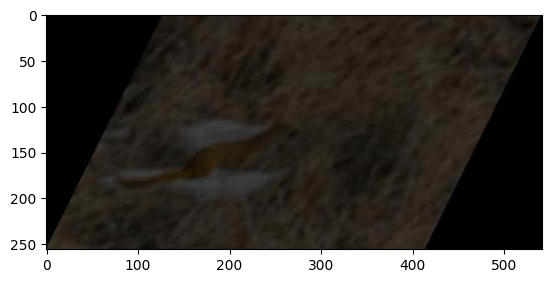

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2 as cv

image = cv.imread('/content/l3pic.jpg')

rgb_image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
plt.imshow(rgb_image)

In [4]:
height, width = rgb_image.shape[:2]

#Подсчет количества черных пикселей в верхнем ряду, идущих подряд
first_row = rgb_image[0]
mask = np.all(first_row == [0, 0, 0], axis=1)
black_len = np.argmax(~mask) if not np.all(mask) else len(mask)
print(black_len)

112


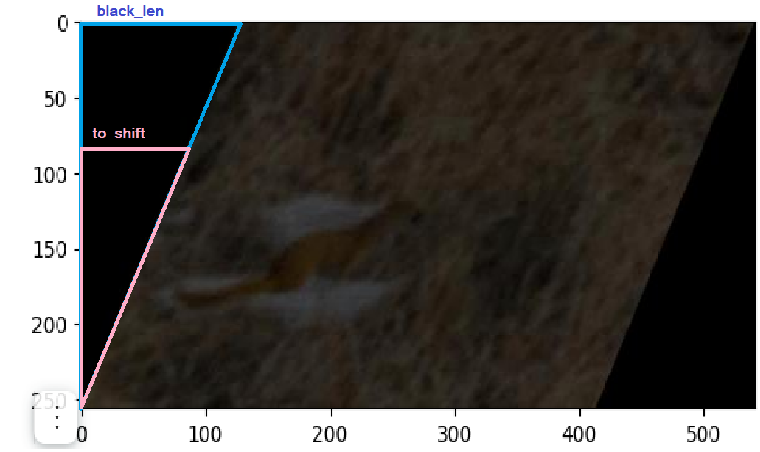

Теперь мы итерационно сможем вычислять количество пикселей, на которое надо сдвинуть строчку картинки. На каждой итерации у нас будет треугольник, подобный исходному (синенькому). Нам известны катеты синенького треугольника и один катет розовенького. Пользуясь математикой за 6 класс и свойствами пропорции, будем искать второй катет
### Изображение после сдвига и обрезки:

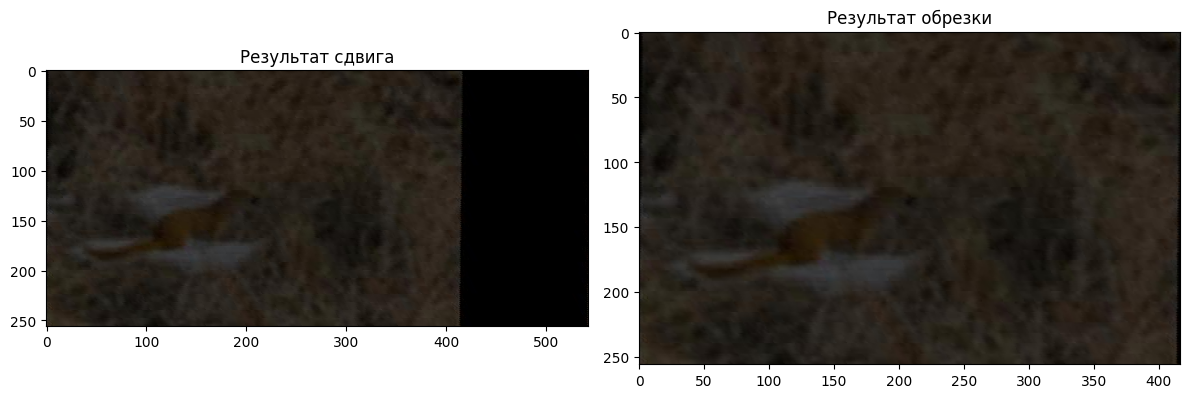

In [37]:
new_rows = []
for i in range(height):
    to_shift = int(round((black_len * (height - i)) / (height)))
    shifted_row = np.roll(rgb_image[i], -to_shift, axis=0)
    new_rows.append(shifted_row)

shifted_image = np.array(new_rows, dtype = rgb_image.dtype)

#Обрезка черного поля справа
cropped_image = shifted_image[:, :-black_len, :]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(shifted_image)
axes[0].set_title('Результат сдвига')

axes[1].imshow(cropped_image)
axes[1].set_title('Результат обрезки')

plt.tight_layout()
plt.show()

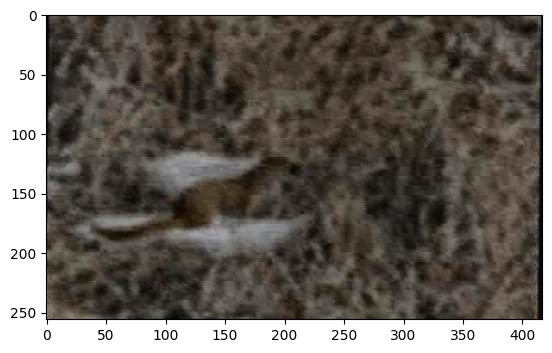

In [7]:
# Выравнивание гистограмм
cl = cv.cvtColor(cropped_image, cv.COLOR_BGR2LAB)
l, a, b = cv.split(cl)

clahe = cv.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
l_clahe = clahe.apply(l)

cl_clahe = cv.merge((l_clahe, a, b))
img_clahe = cv.cvtColor(cl_clahe, cv.COLOR_LAB2BGR)
plt.imshow(img_clahe)

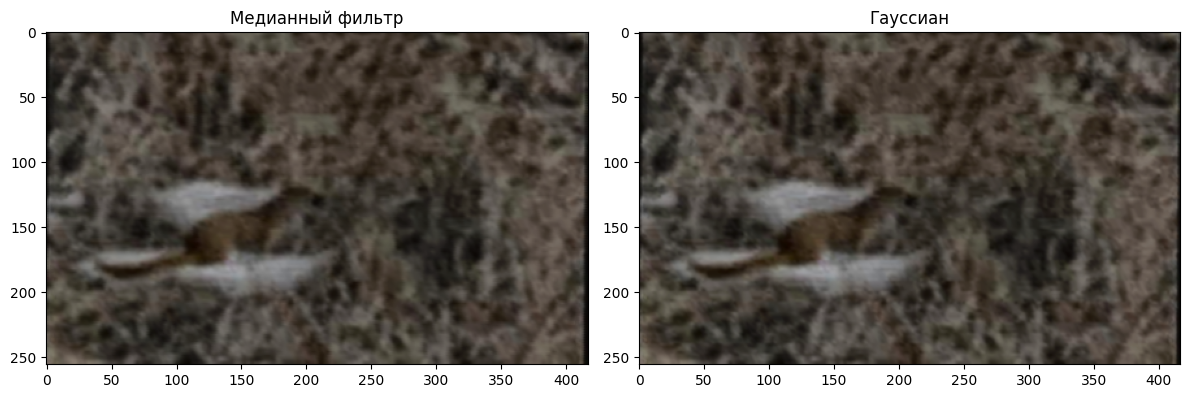

In [38]:
# Повышение резкости
median_kernel = np.array([[0.11, 0.11, 0.11],
                   [0.11, 0.11, 0.11],
                   [0.11, 0.11, 0.11]])
gauss_kernel = np.array([[0.0625, 0.125, 0.0625],
                   [0.125, 0.25, 0.125],
                   [0.0625, 0.125, 0.0625]])
denoised_median_image = cv.filter2D(img_clahe, -1, median_kernel)
denoised_gauss_image = cv.filter2D(img_clahe, -1, gauss_kernel)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(denoised_median_image)
axes[0].set_title('Медианный фильтр')

axes[1].imshow(denoised_gauss_image)
axes[1].set_title('Гауссиан')

plt.tight_layout()
plt.show()

In [41]:
# Повышение резкости для изображений после обоих фильтрров
kernel1 = np.array([[-1, -1, -1],
                   [-1, 9,-1],
                   [-1, -1, -1]])
kernel2 = np.array([[-0.25, -0.25, -0.25],
                   [-0.25, 3, -0.25],
                   [-0.25, -0.25, -0.25]])
kernel3 = np.array([[0, -0.25, 0],
                   [-0.25, 2,-0.25],
                   [0, -0.25, 0]])
sharp_image_median_k1 = cv.filter2D(denoised_median_image, -1, kernel1)
sharp_image_median_k2 = cv.filter2D(denoised_median_image, -1, kernel2)
sharp_image_median_k3 = cv.filter2D(denoised_median_image, -1, kernel3)

sharp_image_gauss_k1 = cv.filter2D(denoised_gauss_image, -1, kernel1)
sharp_image_gauss_k2 = cv.filter2D(denoised_gauss_image, -1, kernel2)
sharp_image_gauss_k3 = cv.filter2D(denoised_gauss_image, -1, kernel3)

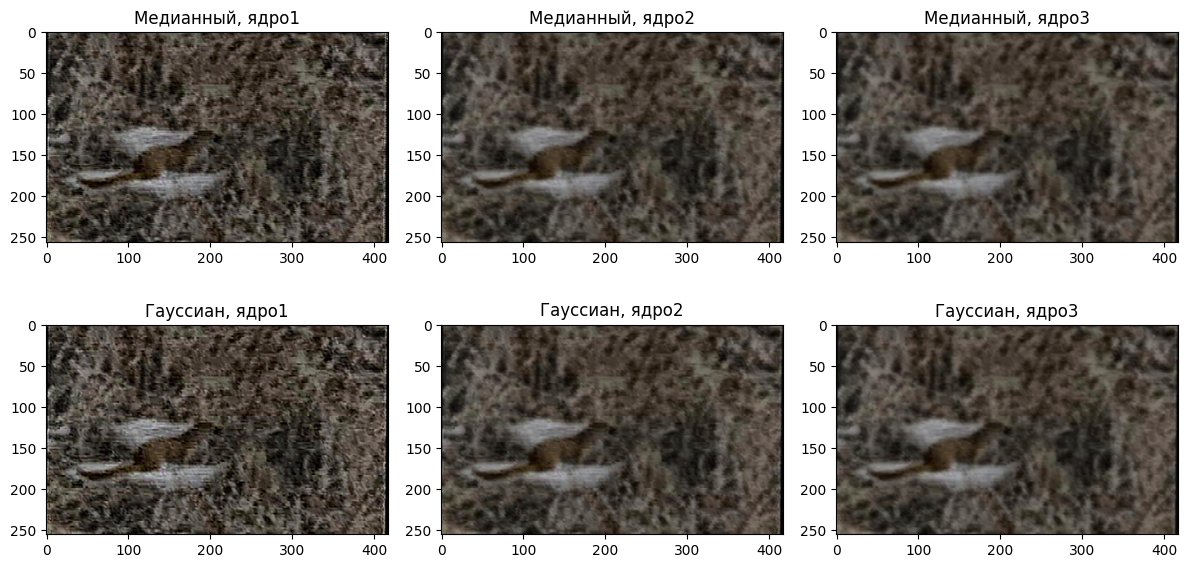

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes[0][0].imshow(sharp_image_median_k1)
axes[0][0].set_title('Медианный, ядро1')

axes[0][1].imshow(sharp_image_median_k2)
axes[0][1].set_title('Медианный, ядро2')

axes[0][2].imshow(sharp_image_median_k3)
axes[0][2].set_title('Медианный, ядро3')

axes[1][0].imshow(sharp_image_gauss_k1)
axes[1][0].set_title('Гауссиан, ядро1')

axes[1][1].imshow(sharp_image_gauss_k2)
axes[1][1].set_title('Гауссиан, ядро2')

axes[1][2].imshow(sharp_image_gauss_k3)
axes[1][2].set_title('Гауссиан, ядро3')

plt.tight_layout()
plt.show()

Субъективно лучше всего выглядит изображение после фильтрации гауссовым фильтром и улучшения резкости ядром 3

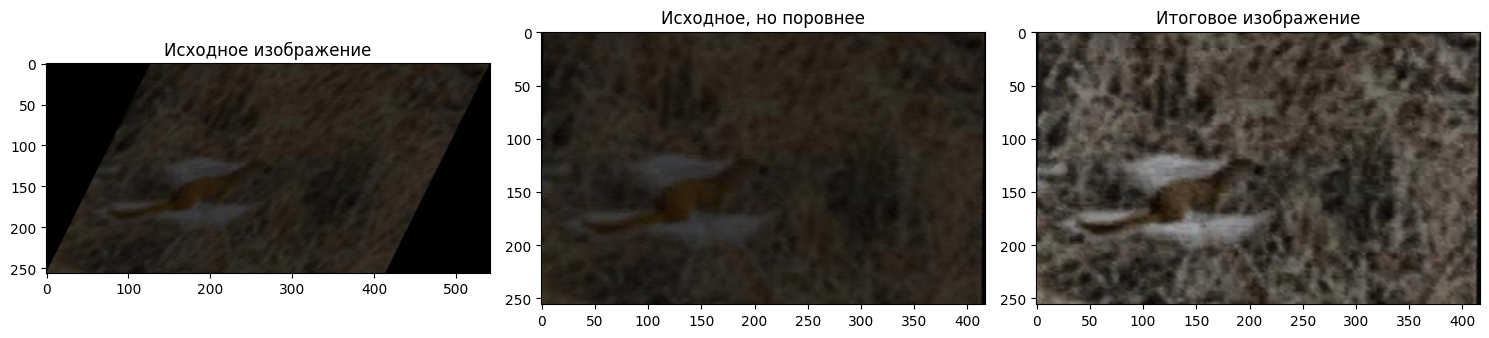

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
axes[0].imshow(rgb_image)
axes[0].set_title('Исходное изображение')

axes[1].imshow(cropped_image)
axes[1].set_title('Исходное, но поровнее')

axes[2].imshow(sharp_image_gauss_k3)
axes[2].set_title('Итоговое изображение')

plt.tight_layout()
plt.show()